In [16]:
""" 
Created on 16-08-2026

@author: B.A. Sturre

EDA for SaaS dataset 
"""

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

# matplotlib setup
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "dejavuserif"
})

In [17]:
# reading in the data 
accounts = pd.read_csv('data/ravenstack_accounts.csv')
churns = pd.read_csv('data/ravenstack_churn_events.csv')
feature = pd.read_csv('data/ravenstack_feature_usage.csv')
subs = pd.read_csv('data/ravenstack_subscriptions.csv')
support = pd.read_csv('data/ravenstack_support_tickets.csv')

# finding the columns
print('accounts columns: ', accounts.columns)
print('churns columns: ', churns.columns)
print('feature columns: ', feature.columns)
print('subs columns: ', subs.columns)
print('support columns: ', support.columns)

accounts columns:  Index(['account_id', 'account_name', 'industry', 'country', 'signup_date',
       'referral_source', 'plan_tier', 'seats', 'is_trial', 'churn_flag'],
      dtype='str')
churns columns:  Index(['churn_event_id', 'account_id', 'churn_date', 'reason_code',
       'refund_amount_usd', 'preceding_upgrade_flag',
       'preceding_downgrade_flag', 'is_reactivation', 'feedback_text'],
      dtype='str')
feature columns:  Index(['usage_id', 'subscription_id', 'usage_date', 'feature_name',
       'usage_count', 'usage_duration_secs', 'error_count', 'is_beta_feature'],
      dtype='str')
subs columns:  Index(['subscription_id', 'account_id', 'start_date', 'end_date', 'plan_tier',
       'seats', 'mrr_amount', 'arr_amount', 'is_trial', 'upgrade_flag',
       'downgrade_flag', 'churn_flag', 'billing_frequency', 'auto_renew_flag'],
      dtype='str')
support columns:  Index(['ticket_id', 'account_id', 'submitted_at', 'closed_at',
       'resolution_time_hours', 'priority', 'first_

In [18]:
# preprocessing data 

# aggregating feature usage by subscription id
feature_agg = feature.groupby('subscription_id').agg(
    total_usage_count=('usage_count', 'sum'),
    total_usage_duration_min=('usage_duration_secs', lambda x: x.sum() / 60),
    total_error_count=('error_count', 'sum')
).reset_index()

# aggregating support aggregation by account id 
support_agg = support.groupby('account_id').agg(
    total_tickets=('ticket_id', 'count'),
    avg_resolution_hours=('resolution_time_hours', 'mean'),
    avg_satisfaction_score=('satisfaction_score', 'mean'),
    total_escalations=('escalation_flag', 'sum')
).reset_index()

# merging datasets
df = subs.merge(feature_agg, on='subscription_id', how='left')
df = df.merge(accounts[['account_id', 'industry', 'country', 'referral_source']], on='account_id', how='left')
df = df.merge(support_agg, on='account_id', how='left')

# fill NaN values for accounts with zero usage
df['total_usage_count'] = df['total_usage_count'].fillna(0)
df['total_error_count'] = df['total_error_count'].fillna(0)
df['total_tickets'] = df['total_tickets'].fillna(0)
df['total_escalations'] = df['total_escalations'].fillna(0)

# create account size categories
df['account_size_category'] = pd.cut(
    df['seats'], 
    bins=[0, 5, 20, 50, np.inf], 
    labels=['Micro (1-5)', 'Small (6-20)', 'Medium (21-50)', 'Enterprise (50+)']
)

print(f"raw merged shape after data preprocessing: {df.shape[0]} rows, {df.shape[1]} columns")

raw merged shape after data preprocessing: 5000 rows, 25 columns


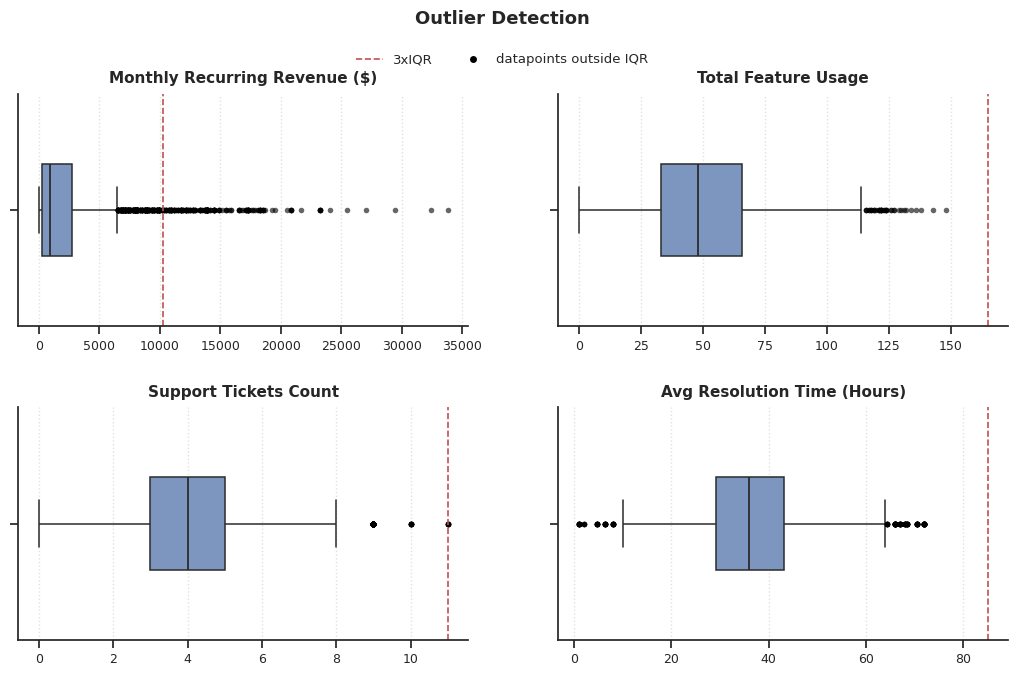

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Professional theme settings
sns.set_theme(style="ticks")
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
    }
)

# Column mapping for clean publication labels
metric_labels = {
    "mrr_amount": "Monthly Recurring Revenue ($)",
    "total_usage_count": "Total Feature Usage",
    "total_tickets": "Support Tickets Count",
    "avg_resolution_hours": "Avg Resolution Time (Hours)",
}

outlier_cols = list(metric_labels.keys())

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharey=False)
fig.suptitle(
    "Outlier Detection",
    fontsize=13,
    fontweight="bold",
    y=0.98,
)

line_handle = None

for idx, col in enumerate(outlier_cols):
  ax = axes[idx // 2, idx % 2]

  # Calculate IQR & extreme cutoff
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  extreme_cutoff = q3 + 3.0 * iqr

  # Minimalist Boxplot
  sns.boxplot(
      x=df[col],
      ax=ax,
      color="#7293CB",
      width=0.4,
      fliersize=4,
      flierprops=dict(
          marker="o",
          markerfacecolor="black",
          markeredgecolor="none",
          alpha=0.6,
      ),
      boxprops=dict(edgecolor="#2B2B2B", linewidth=1.1),
      whiskerprops=dict(color="#2B2B2B", linewidth=1.1),
      capprops=dict(color="#2B2B2B", linewidth=1.1),
      medianprops=dict(color="#2B2B2B", linewidth=1.3),
  )

  # Cutoff line
  line = ax.axvline(
      extreme_cutoff,
      color="#C44E52",
      linestyle="--",
      linewidth=1.2,
      label="3xIQR",
  )
  if line_handle is None:
    line_handle = line

  # Clean presentation styling
  ax.set_title(metric_labels[col], fontweight="bold", pad=8)
  ax.set_xlabel("")
  ax.grid(True, axis="x", linestyle=":", alpha=0.6)
  sns.despine(ax=ax)

# Single unified legend at top
fig.legend(
    handles=[
        line_handle,
        plt.Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            markerfacecolor="black",
            markersize=6,
            label="datapoints outside IQR",
        ),
    ],
    loc="upper center",
    bbox_to_anchor=(0.5, 0.935),
    ncols=2,
    frameon=False,
    fontsize=9.5,
)

plt.subplots_adjust(
    top=0.86, bottom=0.08, left=0.06, right=0.96, hspace=0.35, wspace=0.2
)
plt.savefig('./figures/outlier_detection.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [20]:
def remove_outliers(df, columns, iqr_multiplier=3.0):
    df_clean = df.copy()
    initial_count = len(df_clean)
    
    print("--- Outlier Removal Summary ---")
    for col in columns:
        valid_data = df_clean[col].dropna()
        q1 = valid_data.quantile(0.25)
        q3 = valid_data.quantile(0.75)
        iqr = q3 - q1
        
        # outlier bounds
        upper_bound = q3 + (iqr_multiplier * iqr)
        lower_bound = q1 - (iqr_multiplier * iqr)
        
        # identify outliers
        outlier_mask = (df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)
        num_outliers = outlier_mask.sum()
        
        # drop outliers
        df_clean = df_clean[~outlier_mask]
        print(f"Dropped {num_outliers} rows from '{col}' exceeding bounds [{lower_bound:.2f}, {upper_bound:.2f}]")
    
    final_count = len(df_clean)
    dropped_total = initial_count - final_count
    print(f"\nTotal rows before: {initial_count}")
    print(f"Total rows after:  {final_count}")
    print(f"Total removed:     {dropped_total} ({dropped_total / initial_count * 100:.2f}% of dataset)")
    
    return df_clean


# remove outliers
df_clean = remove_outliers(
    df, 
    columns=['mrr_amount', 'total_usage_count', 'total_tickets', 'avg_resolution_hours'], 
    iqr_multiplier=3.0
)

--- Outlier Removal Summary ---
Dropped 199 rows from 'mrr_amount' exceeding bounds [-7218.00, 10289.00]
Dropped 0 rows from 'total_usage_count' exceeding bounds [-66.00, 165.00]
Dropped 0 rows from 'total_tickets' exceeding bounds [-3.00, 11.00]
Dropped 0 rows from 'avg_resolution_hours' exceeding bounds [-12.93, 85.20]

Total rows before: 5000
Total rows after:  4801
Total removed:     199 (3.98% of dataset)


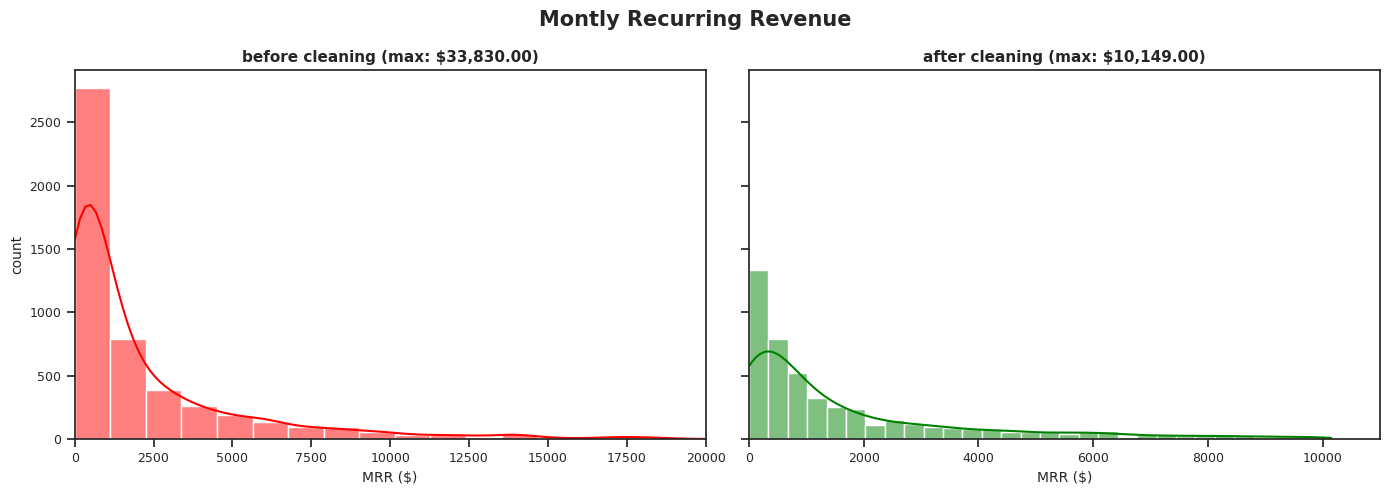

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# befoore cleaning
sns.histplot(df['mrr_amount'], kde=True, ax=axes[0], color='red', bins=30)
axes[0].set_title(f"before cleaning (max: ${df['mrr_amount'].max():,.2f})", fontweight='bold')
axes[0].set_xlim(0, 20000)
axes[0].set_ylabel('count')
axes[0].set_xlabel('MRR ($)')

# after cleaning
sns.histplot(df_clean['mrr_amount'], kde=True, ax=axes[1], color='green', bins=30)
axes[1].set_title(f"after cleaning (max: ${df_clean['mrr_amount'].max():,.2f})", fontweight='bold')
axes[1].set_xlim(0, 11000)
axes[1].set_xlabel('MRR ($)')

plt.suptitle('Montly Recurring Revenue', fontweight='bold', fontsize=15)

plt.tight_layout()
plt.savefig('./figures/distributions_before_after_cleaning.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

## Suggested Projects

- Churn prediction using subscriptions + support data

- Feature adoption tracking during beta phases

- Support workload forecasting

- Revenue cohort analysis by referral channel

- Plan tier upgrade funnel by industry

- Latency analysis by seat count and plan tier